# Regression Performance Metrics: R² and Adjusted R²

## Goal

Evaluate how well a regression model explains and predicts numeric targets. By the end, you will be able to:

- distinguish residual variation from total target variation;
- calculate SSE, SST, $R^2$, and adjusted $R^2$;
- interpret perfect, baseline, and negative $R^2$;
- explain why training $R^2$ cannot decrease when predictors are added to ordinary least squares;
- show how adjusted $R^2$ penalizes unnecessary complexity;
- avoid confusing $R^2$ with classification accuracy;
- combine goodness-of-fit metrics with MAE/RMSE and held-out evaluation.

**Source material:** the supplied performance-metrics transcript and slides. The original examples are retained, but notation and interpretation are corrected where needed.


## 1. Residuals and the mean baseline

For observation $i$:

- true target: $y_i$;
- model prediction: $\hat y_i$;
- residual: $e_i=y_i-\hat y_i$;
- mean target: $\bar y=\frac{1}{n}\sum_i y_i$.

Two sums of squares are central:

### Residual sum of squares

$$
\boxed{\operatorname{SSE}=\sum_{i=1}^{n}(y_i-\hat y_i)^2}
$$

This measures variation left unexplained by the model. It is also called RSS in some books. Acronyms differ across sources, so rely on the formula.

### Total sum of squares

$$
\boxed{\operatorname{SST}=\sum_{i=1}^{n}(y_i-\bar y)^2}
$$

SST measures the target's total variation around a simple baseline that always predicts the mean.

The denominator uses $\bar y$, not $\hat y_i$. The transcript uses similar spoken notation for both; keeping them distinct prevents confusion.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

y_true = np.array([3.0, 5.0, 7.0, 8.0, 11.0])
y_pred = np.array([3.6, 4.7, 6.8, 8.9, 10.3])
y_mean = y_true.mean()

sse = np.sum((y_true - y_pred) ** 2)
sst = np.sum((y_true - y_mean) ** 2)

print("Mean target:", y_mean)
print("SSE (model residual variation):", round(sse, 4))
print("SST (total variation):", round(sst, 4))


Mean target: 6.8
SSE (model residual variation): 1.79
SST (total variation): 36.8


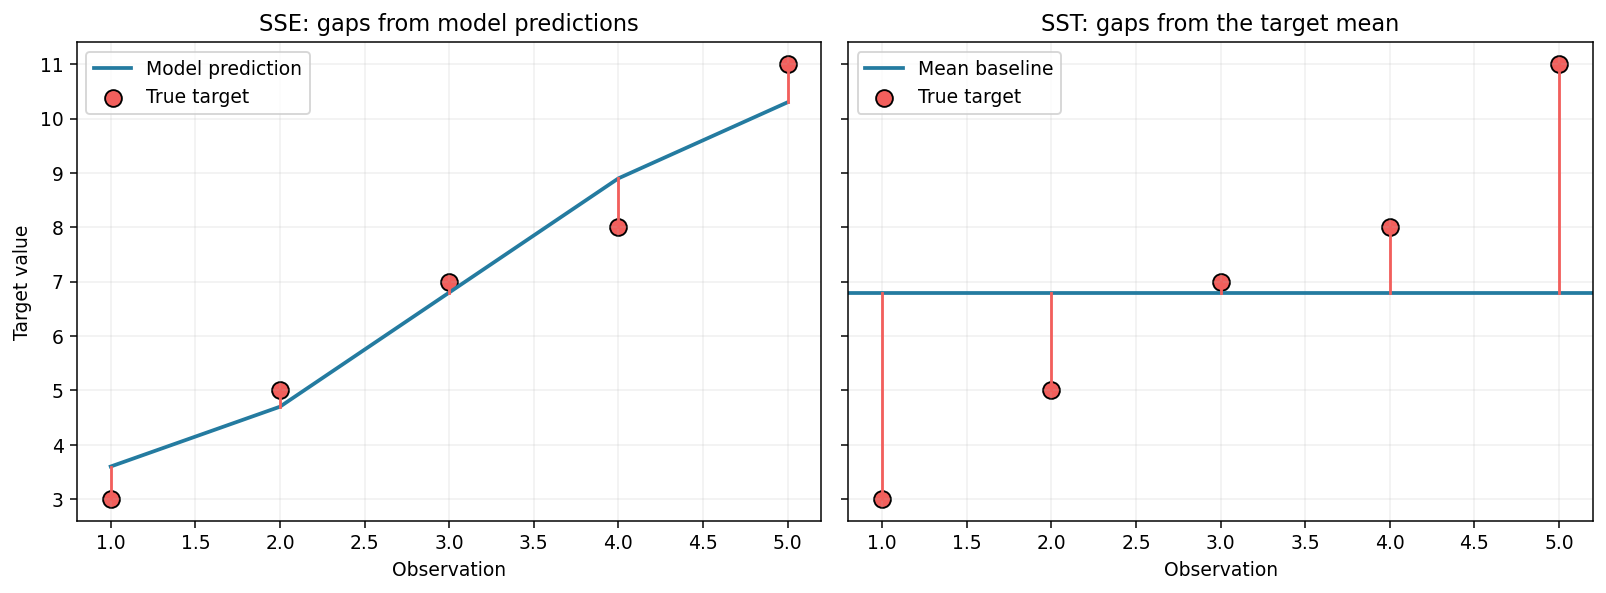

In [2]:
x_index = np.arange(1, len(y_true) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

axes[0].plot(x_index, y_pred, color="#247BA0", linewidth=2, label="Model prediction")
axes[0].scatter(x_index, y_true, s=80, color="#F25F5C", edgecolor="black", label="True target")
for x_i, y_i, y_hat_i in zip(x_index, y_true, y_pred):
    axes[0].plot([x_i, x_i], [y_i, y_hat_i], color="#F25F5C", linewidth=1.5)
axes[0].set_title("SSE: gaps from model predictions")
axes[0].set_xlabel("Observation")
axes[0].set_ylabel("Target value")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].axhline(y_mean, color="#247BA0", linewidth=2, label="Mean baseline")
axes[1].scatter(x_index, y_true, s=80, color="#F25F5C", edgecolor="black", label="True target")
for x_i, y_i in zip(x_index, y_true):
    axes[1].plot([x_i, x_i], [y_i, y_mean], color="#F25F5C", linewidth=1.5)
axes[1].set_title("SST: gaps from the target mean")
axes[1].set_xlabel("Observation")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()


## 2. R-squared

The coefficient of determination is:

$$
\boxed{R^2=1-\frac{\operatorname{SSE}}{\operatorname{SST}}}
$$

It compares the model with the mean-prediction baseline.

- $R^2=1$: perfect predictions on the evaluated data.
- $R^2=0$: the model is no better than always predicting $\bar y$ under squared error.
- $R^2<0$: the model is worse than that mean baseline.

An $R^2$ of $0.70$ is often described as “70% of the target variance is explained by the model” in the evaluated sample. It is **not 70% classification accuracy**, and it does not mean 70% of individual predictions are correct.

$R^2$ is usually at most 1, but it has no fixed lower bound. Negative values commonly occur on test data or for models fitted without an intercept.


In [3]:
r_squared = 1 - sse / sst
print(f"R² = 1 - {sse:.4f}/{sst:.4f} = {r_squared:.4f}")
print(f"Variance-explanation wording: approximately {100 * r_squared:.1f}% on this sample")


R² = 1 - 1.7900/36.8000 = 0.9514
Variance-explanation wording: approximately 95.1% on this sample


## 3. Three reference cases

Consider one true target vector and three sets of predictions:

1. **Perfect model:** $\hat y_i=y_i$, so SSE = 0 and $R^2=1$.
2. **Mean baseline:** $\hat y_i=\bar y$, so SSE = SST and $R^2=0$.
3. **Poor model:** SSE > SST, so $R^2<0$.

These cases make $R^2$ easier to remember than the formula alone.


In [4]:
def r2_score_manual(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    total = np.sum((actual - actual.mean()) ** 2)
    if np.isclose(total, 0):
        raise ValueError("R² is undefined when every true target is identical")
    return 1 - np.sum((actual - predicted) ** 2) / total


prediction_cases = {
    "Perfect": y_true.copy(),
    "Mean baseline": np.full_like(y_true, y_true.mean()),
    "Poor": np.array([11.0, 10.0, 8.0, 5.0, 3.0]),
}

for name, predictions in prediction_cases.items():
    print(f"{name:13s}: R² = {r2_score_manual(y_true, predictions):.3f}")


Perfect      : R² = 1.000
Mean baseline: R² = 0.000
Poor         : R² = -3.429


## 4. Why training R² rises when features are added

For ordinary least squares fitted **with an intercept on the same training rows**, adding a predictor cannot make the minimum training SSE larger. The enlarged model can always set the new coefficient to zero and reproduce the old fit.

Therefore, training $R^2$ can increase or stay the same—even when a new feature contains only noise.

This does **not** mean every added feature is useful. It may improve the training fit by a tiny accidental amount and hurt performance on unseen data.

On validation or test data, $R^2$ can freely increase or decrease when a feature is added because the model is not optimized on those rows.


## 5. Adjusted R-squared

Adjusted $R^2$ adds a complexity penalty:

$$
\boxed{\bar R^2=1-(1-R^2)\frac{n-1}{n-p-1}}
$$

where:

- $n$ is the number of evaluated training observations;
- $p$ is the number of predictor features, excluding the intercept;
- the formula requires $n>p+1$.

Adjusted $R^2$ increases only when a new predictor reduces SSE enough to overcome the penalty. Otherwise, it decreases.

It is more precise to say that adjusted $R^2$ rewards **incremental explanatory contribution after accounting for model size**. A feature does not need strong raw correlation with $y$ to help; it may become useful after controlling for other features.


In [5]:
def adjusted_r2(r_squared, n_observations, n_predictors):
    if n_observations <= n_predictors + 1:
        raise ValueError("Adjusted R² requires n > p + 1")
    return 1 - (1 - r_squared) * (n_observations - 1) / (
        n_observations - n_predictors - 1
    )


example_r2 = 0.90
print("R²:", example_r2)
print("Adjusted R² with n=100 and p=2:", round(adjusted_r2(example_r2, 100, 2), 4))
print("Adjusted R² with n=100 and p=10:", round(adjusted_r2(example_r2, 100, 10), 4))


R²: 0.9
Adjusted R² with n=100 and p=2: 0.8979
Adjusted R² with n=100 and p=10: 0.8888


## 6. Demonstration: useful and irrelevant features

We will fit three models to the same synthetic training data:

- Model A: one genuinely useful feature $x_1$;
- Model B: $x_1$ plus a random noise feature;
- Model C: $x_1$ plus a second useful feature $x_2$.

Ordinary training $R^2$ should not decrease as columns are added. Adjusted $R^2$ may decrease for the noise feature and increase for the useful feature.


In [6]:
rng = np.random.default_rng(2)
n = 80
x1 = rng.normal(size=n)
x2_useful = rng.normal(size=n)
x_noise = rng.normal(size=n)
y = 5 + 2.5 * x1 - 1.8 * x2_useful + rng.normal(scale=1.0, size=n)


def fit_and_score(feature_columns, target):
    design = np.column_stack([np.ones(len(target)), *feature_columns])
    beta, *_ = np.linalg.lstsq(design, target, rcond=None)
    predictions = design @ beta
    r2 = r2_score_manual(target, predictions)
    p = len(feature_columns)
    return r2, adjusted_r2(r2, len(target), p)


models = {
    "A: x1 only": [x1],
    "B: x1 + noise": [x1, x_noise],
    "C: x1 + useful x2": [x1, x2_useful],
}

results = {}
for name, columns in models.items():
    results[name] = fit_and_score(columns, y)
    print(f"{name:20s} R²={results[name][0]:.4f}  adjusted R²={results[name][1]:.4f}")


A: x1 only           R²=0.5963  adjusted R²=0.5912
B: x1 + noise        R²=0.5972  adjusted R²=0.5868
C: x1 + useful x2    R²=0.8992  adjusted R²=0.8965


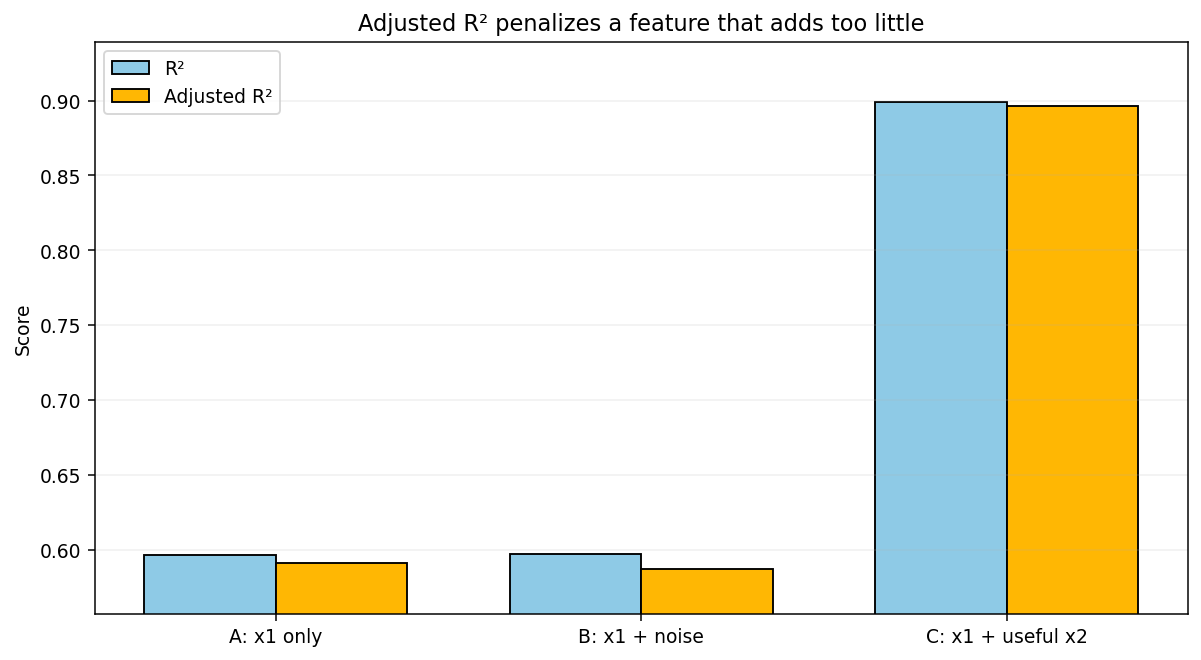

In [7]:
names = list(results)
r2_values = [results[name][0] for name in names]
adjusted_values = [results[name][1] for name in names]
positions = np.arange(len(names))
width = 0.36

plt.figure(figsize=(9, 5))
plt.bar(positions - width / 2, r2_values, width, label="R²", color="#8ECAE6", edgecolor="black")
plt.bar(positions + width / 2, adjusted_values, width, label="Adjusted R²", color="#FFB703", edgecolor="black")
plt.xticks(positions, names)
plt.ylabel("Score")
plt.title("Adjusted R² penalizes a feature that adds too little")
plt.ylim(min(adjusted_values) - 0.03, max(r2_values) + 0.04)
plt.grid(axis="y", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


The exact values depend on the random sample, but the logic is stable:

- training $R^2$ stays the same or increases when a feature is added;
- adjusted $R^2$ asks whether that increase is large enough to justify another predictor;
- a truly useful added feature can raise both scores substantially.

Adjusted $R^2$ is still not a replacement for held-out evaluation. It is an in-sample complexity adjustment under a specific linear-model setting.


## 7. R² versus error metrics

Use complementary metrics because each answers a different question.

| Metric | What it tells you | Units |
|---|---|---|
| $R^2$ | Improvement over the mean baseline | Unitless |
| Adjusted $R^2$ | In-sample fit adjusted for predictor count | Unitless |
| MAE | Average absolute prediction error | Same as target |
| RMSE | Square-root average squared error; emphasizes large errors | Same as target |

A model can have an impressive $R^2$ but errors that are too large for the business use case. Report at least one error metric in the target's units and evaluate on data not used for fitting.


In [8]:
residuals = y_true - y_pred
mae = np.mean(np.abs(residuals))
rmse = np.sqrt(np.mean(residuals ** 2))

print(f"R²:   {r_squared:.4f}")
print(f"MAE:  {mae:.4f} target units")
print(f"RMSE: {rmse:.4f} target units")


R²:   0.9514
MAE:  0.5400 target units
RMSE: 0.5983 target units


## 8. Train, validation, and test interpretation

- **Training metrics** describe fit on the rows used to estimate parameters and are usually optimistic.
- **Validation metrics** help choose features, transformations, and hyperparameters.
- **Test metrics** provide a final estimate on untouched data.

Overfitting often appears as very strong training $R^2$ but much weaker or negative validation/test $R^2$. Never claim generalization from training $R^2$ alone.

When comparing test $R^2$ across datasets, use the same target definition and evaluation rows. Different target variability changes SST, so scores from unrelated datasets are not automatically comparable.


## 9. Edge cases and cautions

- If all true targets are identical, SST = 0 and ordinary $R^2$ is undefined.
- Adjusted $R^2$ is undefined when $n\le p+1$.
- $R^2$ does not show whether residual assumptions are satisfied.
- A high score can coexist with leakage, bias, unstable coefficients, or implausible extrapolation.
- A low $R^2$ can still accompany useful predictions in noisy domains.
- Correlation and $R^2$ do not prove causation.
- For non-linear or no-intercept models, some familiar $R^2$ identities and interpretations require extra care.


## 10. Common mistakes

1. Calling $R^2$ “accuracy.” It is a regression goodness-of-fit score.
2. Using predictions $\hat y_i$ instead of the target mean $\bar y$ in SST.
3. Believing $R^2$ must lie between 0 and 1.
4. Assuming a higher training $R^2$ guarantees better future predictions.
5. Saying adjusted $R^2$ directly measures correlation.
6. Counting the intercept inside $p$ in the standard adjusted-$R^2$ formula.
7. Comparing models evaluated on different target rows.
8. Reporting only $R^2$ without an error metric in meaningful units.


## 11. Quick revision sheet

- **Residual:** $e_i=y_i-\hat y_i$.
- **SSE/RSS:** $\sum_i(y_i-\hat y_i)^2$.
- **SST:** $\sum_i(y_i-\bar y)^2$.
- **R²:** $1-\mathrm{SSE}/\mathrm{SST}$.
- **R² = 1:** perfect on evaluated data.
- **R² = 0:** same squared-error performance as mean baseline.
- **R² < 0:** worse than mean baseline.
- **Adjusted R²:** $1-(1-R^2)(n-1)/(n-p-1)$.
- **$n$:** observations.
- **$p$:** predictor features, excluding intercept.
- **Added predictor:** training $R^2$ cannot decrease in intercept-based OLS; adjusted $R^2$ can.
- **Generalization:** judge on held-out data, not training fit alone.


## 12. Quick questions — answer before checking below

1. What is a residual?
2. Write the formula for SSE.
3. Write the formula for SST.
4. Which value appears in SST: $\hat y_i$ or $\bar y$?
5. Write the formula for $R^2$.
6. What does $R^2=1$ mean?
7. What does $R^2=0$ mean?
8. Can $R^2$ be negative?
9. Is $R^2=0.80$ the same as 80% classification accuracy?
10. Why can training $R^2$ rise after adding a noise feature?
11. Write the adjusted-$R^2$ formula.
12. What do $n$ and $p$ mean in that formula?
13. When does adjusted $R^2$ decrease after adding a feature?
14. Why should MAE or RMSE be reported alongside $R^2$?
15. Which split should provide the final unbiased model assessment?


## 13. Answer key

1. The difference between a true target and its prediction, commonly $y_i-\hat y_i$.
2. $\mathrm{SSE}=\sum_i(y_i-\hat y_i)^2$.
3. $\mathrm{SST}=\sum_i(y_i-\bar y)^2$.
4. The target mean $\bar y$.
5. $R^2=1-\mathrm{SSE}/\mathrm{SST}$.
6. Predictions are perfect on the evaluated rows, so SSE is zero.
7. The model matches the mean baseline under squared error.
8. Yes. It means the predictions are worse than the mean baseline on those rows.
9. No. $R^2$ is not classification accuracy.
10. Least squares can set the new coefficient to zero or use accidental sample noise to reduce training SSE slightly.
11. $\bar R^2=1-(1-R^2)(n-1)/(n-p-1)$.
12. $n$ is the observation count; $p$ is the number of predictor features excluding the intercept.
13. When the new feature's reduction in SSE is too small to overcome the complexity penalty.
14. They express typical prediction error in the target's units and expose practical error size.
15. An untouched test set, after all choices have been made using training/validation data.
